<a href="https://colab.research.google.com/github/AlvPD/PE-y-RN/blob/main/Brownian_motion_in_a_magnetic_field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Se importan las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Parámetros
m = 1.0          # Masa
q = 1.0          # Carga
B = 5.0          # Campo magnético
beta = 0.5       # Coeficiente de fricción
kB = 1.0         # Constante de Boltzmann
T = 1.0          # Temperatura
dt = 0.01        # Paso de tiempo
Steps = 10000    # Número de pasos

# Intensidad del ruido (raíz del coeficiente de difusión)
noise_strength = np.sqrt(2 * beta * kB * T)

In [10]:
# Vectores de velocidad (Vx, Vy, Vz)
V = np.zeros((3, Steps))
time = np.linspace(0, Steps*dt, Steps)

# Condiciones iniciales (velocidad v0)
V[:, 0] = [5.0, 0.0, 2.0]  # Empieza con empuje en X y Z

In [11]:
# algoritmo de EULER-MARUYAMA
# La ecuación es m*dV = F_det*dt + F_stoch*dW
# Dividiendo por m: dV = (F_det/m)*dt + (F_stoch/m)*dW

for t in range(Steps - 1):
    vx, vy, vz = V[:, t]

    # Generar ruido blanco Gaussiano independiente para cada componente
    # dW ~ N(0, dt) -> se simula como sqrt(dt) * N(0, 1)
    dW = np.random.normal(0, 1, 3) * np.sqrt(dt)

    # Fuerzas Deterministas (Lorentz + Fricción)

    fx = -beta * vx + q * B * vy
    fy = -beta * vy - q * B * vx
    fz = -beta * vz

    # Actualización de Euler
    V[0, t+1] = vx + (fx / m) * dt + (noise_strength / m) * dW[0]
    V[1, t+1] = vy + (fy / m) * dt + (noise_strength / m) * dW[1]
    V[2, t+1] = vz + (fz / m) * dt + (noise_strength / m) * dW[2]

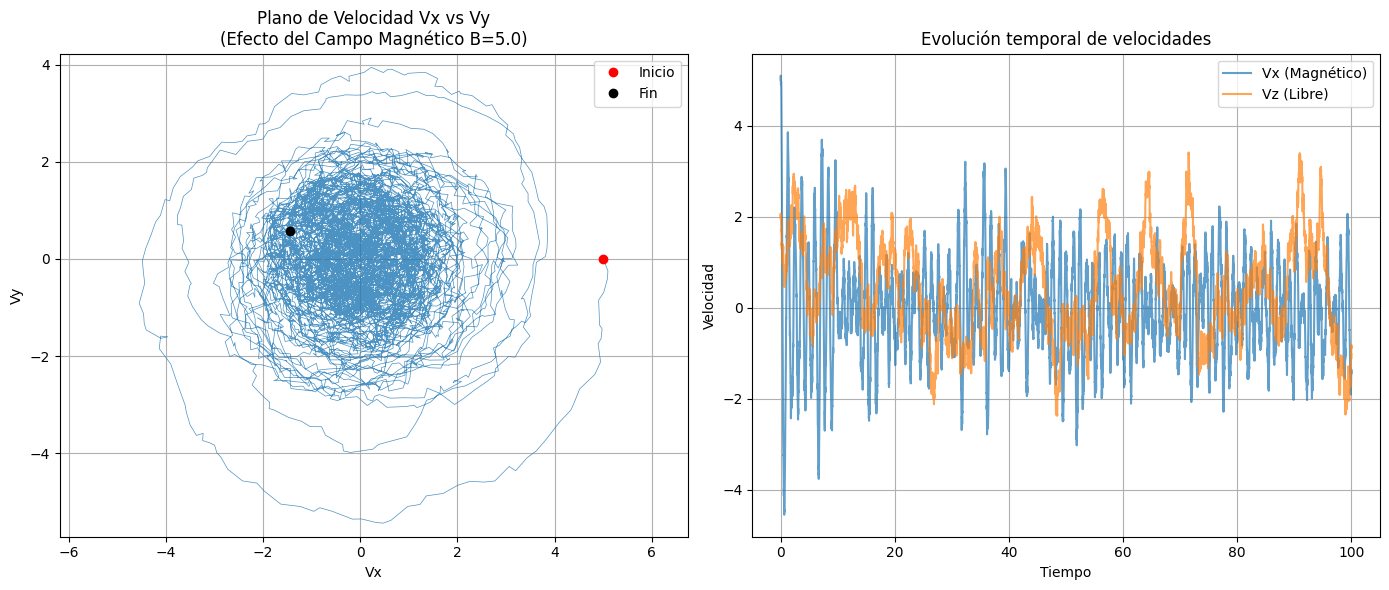

In [12]:
# Graficación

plt.figure(figsize=(14, 6))

# Gráfica A: Espacio de fases de velocidad XY (Ciclotrónico)
plt.subplot(1, 2, 1)
plt.plot(V[0, :], V[1, :], lw=0.5, alpha=0.8)
plt.plot(V[0, 0], V[1, 0], 'ro', label='Inicio') # Punto rojo inicio
plt.plot(V[0, -1], V[1, -1], 'ko', label='Fin')  # Punto negro fin
plt.title(f'Plano de Velocidad Vx vs Vy\n(Efecto del Campo Magnético B={B})')
plt.xlabel('Vx')
plt.ylabel('Vy')
plt.legend()
plt.axis('equal')
plt.grid(True)

# Gráfica B: Evolución Temporal de las componentes
plt.subplot(1, 2, 2)
plt.plot(time, V[0, :], label='Vx (Magnético)', alpha=0.7)
plt.plot(time, V[2, :], label='Vz (Libre)', alpha=0.7)
plt.title('Evolución temporal de velocidades')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1. Gráfica Izquierda (Vx​ vs Vy​): Si B es alto, las espirales son cerradas (el campo magnético domina sobre la fricción y el ruido). Si bajas B, el movimiento se vuelve más caótico ("browniano clásico").
2. Gráfica Derecha (Vx​ vs Tiempo): Notarás que Vx​ oscila (debido a la rotación magnética) mientras decae hacia el equilibrio térmico, a diferencia de Vz​ que solo decae exponencialmente con ruido.